In [1]:
import os
import torch
from PIL import Image
import numpy as np
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim

In [2]:
torch.__version__

'2.9.1+cu126'

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
!dir

 Volume in drive C is Windows
 Volume Serial Number is F8F0-6F8D

 Directory of C:\Users\sahas11\Downloads\py_Torch

14-12-2025  21:38    <DIR>          .
13-12-2025  12:20    <DIR>          ..
14-12-2025  21:32    <DIR>          .ipynb_checkpoints
01-12-2025  13:56    <DIR>          clothing-dataset
14-12-2025  19:36           157,199 clothing_classifier_mobilenet_v2.onnx
14-12-2025  19:36         9,371,648 clothing_classifier_mobilenet_v2.onnx.data
14-12-2025  19:14         9,667,169 clothing_v4_23_0.830.pth
10-12-2025  05:39    <DIR>          data
14-12-2025  21:38           358,200 Homework9.ipynb
07-12-2025  14:30            10,472 imagenet_classes.txt
04-12-2025  18:48           613,914 M9_COPY.ipynb
14-12-2025  20:19         1,078,614 pyTorch Tutorial.ipynb
               7 File(s)     21,257,216 bytes
               5 Dir(s)  164,399,210,496 bytes free


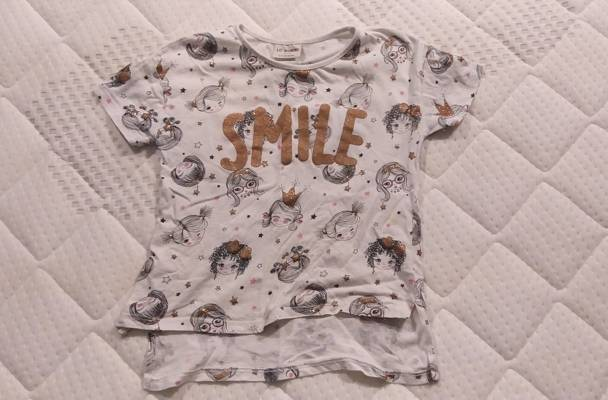

In [5]:
img = Image.open("clothing-dataset/train/t-shirt/0144d8a2-0d3b-4bee-b137-324129e746a8.jpg")
img

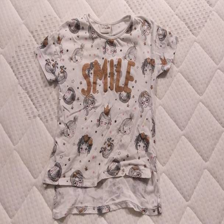

In [6]:
img.resize((224,224))

In [7]:
X = np.array(img.resize((224,224)))
X

array([[[207, 189, 187],
        [207, 189, 187],
        [205, 187, 185],
        ...,
        [224, 206, 204],
        [223, 205, 203],
        [216, 198, 196]],

       [[208, 190, 188],
        [211, 193, 191],
        [206, 188, 186],
        ...,
        [222, 204, 202],
        [223, 205, 203],
        [221, 203, 201]],

       [[209, 191, 189],
        [214, 196, 194],
        [208, 190, 188],
        ...,
        [219, 201, 199],
        [220, 202, 200],
        [221, 203, 201]],

       ...,

       [[196, 177, 171],
        [193, 174, 168],
        [191, 172, 166],
        ...,
        [182, 163, 159],
        [201, 182, 178],
        [197, 178, 174]],

       [[198, 179, 173],
        [194, 175, 169],
        [191, 172, 166],
        ...,
        [186, 167, 163],
        [206, 187, 183],
        [201, 182, 178]],

       [[192, 173, 167],
        [189, 170, 164],
        [188, 169, 163],
        ...,
        [192, 173, 169],
        [201, 182, 178],
        [196, 177, 173]]

In [8]:
X.shape

(224, 224, 3)

In [9]:
# torchvision library has pre-trained models for tmages
# load pre-trained model
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.eval() # using the model only for evaluation, not for training

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [10]:
type(model)

torchvision.models.mobilenetv2.MobileNetV2

In [11]:
type(model.eval())
# To switch between these modes, use model.train() or model.eval() as appropriate
# eval() : Set the module in evaluation mode.

torchvision.models.mobilenetv2.MobileNetV2

In [12]:
# image proprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [13]:
# Normalize(mean, std): Normalizes a tensor with a given mean and standard deviation for each channel,
# which helps speed up model convergence.

In [14]:
preprocess(img)

tensor([[[1.4954, 1.4098, 1.3584,  ..., 1.6495, 1.5297, 1.2214],
         [1.5639, 1.3413, 1.1187,  ..., 1.8208, 1.8037, 1.4440],
         [1.5125, 1.4440, 1.3584,  ..., 1.7523, 1.8550, 1.8550],
         ...,
         [1.4783, 1.5639, 1.3927,  ..., 1.2043, 1.1700, 1.2385],
         [1.4783, 1.4440, 1.4612,  ..., 1.3584, 1.3584, 1.3242],
         [1.4440, 1.4098, 1.4269,  ..., 1.3584, 1.3584, 1.2899]],

        [[1.3431, 1.2556, 1.2031,  ..., 1.5007, 1.3782, 1.0630],
         [1.4132, 1.1856, 0.9580,  ..., 1.6758, 1.6583, 1.2906],
         [1.3606, 1.2906, 1.2031,  ..., 1.6057, 1.7108, 1.7108],
         ...,
         [1.3081, 1.3957, 1.2206,  ..., 1.0105, 0.9755, 1.0455],
         [1.3081, 1.2731, 1.2906,  ..., 1.1681, 1.1681, 1.1331],
         [1.2731, 1.2381, 1.2556,  ..., 1.1681, 1.1681, 1.0980]],

        [[1.4897, 1.4025, 1.3502,  ..., 1.6465, 1.5245, 1.2108],
         [1.5594, 1.3328, 1.1062,  ..., 1.8208, 1.8034, 1.4374],
         [1.5071, 1.4374, 1.3502,  ..., 1.7511, 1.8557, 1.

In [15]:
preprocess(img).shape

torch.Size([3, 224, 224])

In [16]:
x = preprocess(img)

In [17]:
# convert the image tensor to a batch, a batch contains multiple images in a tensor
batch_t = torch.unsqueeze(x, 0).to(device)
batch_t.shape

torch.Size([1, 3, 224, 224])

In [18]:
x.shape

torch.Size([3, 224, 224])

In [20]:
# make prediction
with torch.no_grad(): # no_grad means we are not training the model, we are using/evaluating the model
    output = model(batch_t.to('cpu'))

In [21]:
output.shape
# (1, 1000) means 1 image with 1000 class predictions (probabilities)

torch.Size([1, 1000])

In [22]:
_, indices = torch.sort(output, descending=True)
indices

tensor([[610, 697, 793, 797, 842, 529, 411, 465, 885, 841, 443, 750, 775, 638,
         652, 459, 399, 414, 591, 794, 689, 601, 824, 151, 578, 772,  38, 678,
         636, 972, 419, 431, 887, 796, 721, 551, 735, 172, 171, 516, 868, 464,
         111, 970, 520, 861, 823,  66, 978, 251, 445, 639, 477, 434, 830, 474,
         655, 831,  61, 614, 669, 911, 452, 977, 617, 153, 692,  69, 640, 808,
         500, 546, 608, 917,  68, 884, 162, 728, 433, 523, 543,  32, 549, 837,
         126, 711, 883, 927, 253, 646, 906, 921, 556, 752, 748, 691, 929, 688,
         435, 112, 606, 764, 446, 869,  45, 584, 488, 739, 679, 854, 515, 179,
         996,  62, 889, 813, 840, 770, 725, 501, 714, 936, 999, 898, 806, 643,
         457, 586, 189, 785, 905, 182,  41, 847, 541,  60, 327, 599, 879, 451,
         242, 712, 629, 901, 461, 834,  71, 765, 631, 589, 478, 876, 535, 789,
         203, 836, 544, 356,  67, 701, 424, 620, 838, 916, 761, 729, 328, 444,
         188, 899, 619, 700,  54, 762, 818, 875, 741

In [23]:
_

tensor([[ 1.2282e+01,  1.2160e+01,  1.0824e+01,  9.7670e+00,  9.7082e+00,
          9.0550e+00,  8.7644e+00,  8.2383e+00,  8.2142e+00,  8.1767e+00,
          7.8196e+00,  7.7943e+00,  7.6129e+00,  7.4186e+00,  7.3996e+00,
          7.2178e+00,  7.0770e+00,  7.0358e+00,  6.9930e+00,  6.8914e+00,
          6.7664e+00,  6.6834e+00,  6.6508e+00,  6.6503e+00,  6.4517e+00,
          6.4462e+00,  6.3480e+00,  6.3331e+00,  6.2795e+00,  6.2773e+00,
          6.1872e+00,  6.0151e+00,  6.0087e+00,  5.9073e+00,  5.8603e+00,
          5.8385e+00,  5.7967e+00,  5.7839e+00,  5.7752e+00,  5.7064e+00,
          5.5627e+00,  5.4976e+00,  5.4963e+00,  5.4898e+00,  5.4481e+00,
          5.3388e+00,  5.3205e+00,  5.2083e+00,  5.2075e+00,  5.2017e+00,
          5.1967e+00,  5.1727e+00,  5.1635e+00,  5.1259e+00,  5.0695e+00,
          5.0661e+00,  4.8961e+00,  4.8658e+00,  4.8490e+00,  4.8287e+00,
          4.8198e+00,  4.7892e+00,  4.7866e+00,  4.6886e+00,  4.6853e+00,
          4.6734e+00,  4.6517e+00,  4.

In [24]:
# two most likely probs
output[0][610], output[0][697]

(tensor(12.2821), tensor(12.1603))

In [25]:
!curl https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt -O imagenet_classes.txt

<HTML><HEAD>
<TITLE>Network Error</TITLE>
</HEAD>
<BODY>
<FONT face="Helvetica">
<big><strong></strong></big><BR>
</FONT>
<blockquote>
<TABLE border=0 cellPadding=1 width="80%">
<TR><TD>
<FONT face="Helvetica">
<big>Network Error (dns_unresolved_hostname)</big>
<BR>
<BR>
</FONT>
</TD></TR>
<TR><TD>
<FONT face="Helvetica">
Your requested host "imagenet_classes.txt" could not be resolved by DNS.
</FONT>
</TD></TR>
<TR><TD>
<FONT face="Helvetica">

</FONT>
</TD></TR>
<TR><TD>
<FONT face="Helvetica" SIZE=2>
<BR>
For assistance, contact your network support team.<br><br>Your request was categorized by Blue Coat Web Filter as 'none'. <br>If you wish to question or dispute this result, please click <a href="http://sitereview.bluecoat.com/sitereview.jsp?referrer=136&url=http://imagenet_classes.txt/">here</a>.
</FONT>
</TD></TR>
</TABLE>
</blockquote>
</FONT>
</BODY></HTML>


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
 66 10472   66  6890    0     0   3331      0  0:00:03  0:00:02  0:00:01  3336
 79 10472   79  8268    0     0   2841      0  0:00:03  0:00:02  0:00:01  2844
 79 10472   79  8268    0     0   2114      0  0:00:04  0:00:03  0:00:01  2115
100 10472  100 10472    0     0   2545      0  0:00:04  0:00:04 --:--:--  2548
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   914  100   914    0     0   1454      0 --:--:-- --:--:-- --:--:--  1457


In [26]:
# find the class name from the txt file : imagenet_classes.txt
with open("imagenet_classes.txt", 'r') as f:
    categories = [s.strip() for s in f.readlines()]

#get top 5 predictions
top5_indices = indices[0, :5].tolist()
print(top5_indices)
top5_classes = [categories[i] for i in top5_indices]

print('Top 5 Predictions: ')
for i, class_name in enumerate(top5_classes):
    print(f'{i+1}: {class_name}')

[610, 697, 793, 797, 842]
Top 5 Predictions: 
1: jersey
2: pajama
3: shower cap
4: sleeping bag
5: swimming trunks


In [27]:
## Transfer Learning
class ClothingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i,cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    
    def __len__(self):
        return len(self.image_paths)

    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [28]:
input_size = 224

# ImageNet Normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Simple transforms - just resize and normalize
train_transforms = transforms.Compose([
    # transforms.Resize((input_size, input_size))
    transforms.RandomRotation(10),           # Rotate up to 10 degrees
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),  # Zoom
    transforms.RandomHorizontalFlip(),       # Horizontal flip
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [29]:
train_dataset = ClothingDataset(
    data_dir='./clothing-dataset/train',
    transform=train_transforms
)

val_dataset = ClothingDataset(
    data_dir='./clothing-dataset/validation',
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [30]:
classes = list(train_dataset.class_to_idx)
classes

['dress',
 'hat',
 'longsleeve',
 'outwear',
 'pants',
 'shirt',
 'shoes',
 'shorts',
 'skirt',
 't-shirt']

In [31]:
type(train_loader)

torch.utils.data.dataloader.DataLoader

In [32]:
type(train_transforms)

torchvision.transforms.transforms.Compose

In [33]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        # load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # remove original classifier
        self.base_model.classifier = nn.Identity()

        # add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1,1))
        self.output_layer = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x
        

In [34]:
## Train the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model= ClothingClassifierMobileNet(num_classes=10)
model.to(device)

cuda


ClothingClassifierMobileNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16,

In [35]:
# model.forward(torch.rand(1,3,224,224).to(device))

In [36]:
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [37]:
# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Iterate over the training data
    for inputs, labels in train_loader:
        # Move data to the specified device (GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients to prevent accumulation
        optimizer.zero_grad()
        # Forward pass
        outputs = model(inputs)
        # Calculate the loss
        loss = criterion(outputs, labels)
        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Accumulate training loss
        running_loss += loss.item()
        # Get predictions
        _, predicted = torch.max(outputs.data, 1)
        # Update total and correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate average training loss and accuracy
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Disable gradient calculation for validation
    with torch.no_grad():
        # Iterate over the validation data
        for inputs, labels in val_loader:
            # Move data to the specified device (GPU or CPU)
            inputs, labels = inputs.to(device), labels.to(device)
            # Forward pass
            outputs = model(inputs)
            # Calculate the loss
            loss = criterion(outputs, labels)

            # Accumulate validation loss
            val_loss += loss.item()
            # Get predictions
            _, predicted = torch.max(outputs.data, 1)
            # Update total and correct predictions
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate average validation loss and accuracy
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # Print epoch results
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

Epoch 1/10
  Train Loss: 1.5386, Train Acc: 0.6007
  Val Loss: 0.7853, Val Acc: 0.7683
Epoch 2/10
  Train Loss: 0.8949, Train Acc: 0.7288
  Val Loss: 0.9289, Val Acc: 0.7507
Epoch 3/10
  Train Loss: 0.7037, Train Acc: 0.7787
  Val Loss: 0.8677, Val Acc: 0.7625
Epoch 4/10
  Train Loss: 0.7866, Train Acc: 0.7757
  Val Loss: 1.0709, Val Acc: 0.7361
Epoch 5/10
  Train Loss: 0.7138, Train Acc: 0.7989
  Val Loss: 1.2537, Val Acc: 0.7155
Epoch 6/10
  Train Loss: 0.6840, Train Acc: 0.8067
  Val Loss: 1.7724, Val Acc: 0.6686
Epoch 7/10
  Train Loss: 0.6260, Train Acc: 0.8165
  Val Loss: 1.1369, Val Acc: 0.7595
Epoch 8/10
  Train Loss: 0.6210, Train Acc: 0.8175
  Val Loss: 1.2525, Val Acc: 0.7654
Epoch 9/10
  Train Loss: 0.6682, Train Acc: 0.8136
  Val Loss: 1.2870, Val Acc: 0.7507
Epoch 10/10
  Train Loss: 0.6428, Train Acc: 0.8289
  Val Loss: 1.4431, Val Acc: 0.7478


In [38]:
# tuning the learning rate
def make_model(learning_rate=0.01):
    model = ClothingClassifierMobileNet(num_classes=10)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [39]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    best_val_accuracy = 0.0  # Initialize variable to track the best validation accuracy

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            checkpoint_path = f'clothing_v4_{epoch+1:02d}_{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

In [40]:
# In PyTorch, a state_dict() is a standard Python dictionary that maps each layer of a model to its corresponding parameter tensors (weights and biases).
# It is the recommended method for saving and loading models because it is more flexible and portable than saving entire model objects. 

In [41]:
for lr in [0.001, 0.1]: #0.01, 0.1]:
    print("learning rate =", lr)
    model, optimizer = make_model(lr)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

learning rate = 0.001
Epoch 1/10
  Train Loss: 1.3763, Train Acc: 0.5600
  Val Loss: 0.9036, Val Acc: 0.6745
Checkpoint saved: clothing_v4_01_0.674.pth
Epoch 2/10
  Train Loss: 0.8496, Train Acc: 0.7386
  Val Loss: 0.7146, Val Acc: 0.7830
Checkpoint saved: clothing_v4_02_0.783.pth
Epoch 3/10
  Train Loss: 0.6961, Train Acc: 0.7793
  Val Loss: 0.6438, Val Acc: 0.7742
Epoch 4/10
  Train Loss: 0.6234, Train Acc: 0.7989
  Val Loss: 0.6241, Val Acc: 0.7947
Checkpoint saved: clothing_v4_04_0.795.pth
Epoch 5/10
  Train Loss: 0.5831, Train Acc: 0.8119
  Val Loss: 0.6287, Val Acc: 0.7713
Epoch 6/10
  Train Loss: 0.5435, Train Acc: 0.8211
  Val Loss: 0.5699, Val Acc: 0.8065
Checkpoint saved: clothing_v4_06_0.806.pth
Epoch 7/10
  Train Loss: 0.5134, Train Acc: 0.8312
  Val Loss: 0.6201, Val Acc: 0.7830
Epoch 8/10
  Train Loss: 0.4881, Train Acc: 0.8354
  Val Loss: 0.5725, Val Acc: 0.8152
Checkpoint saved: clothing_v4_08_0.815.pth
Epoch 9/10
  Train Loss: 0.4717, Train Acc: 0.8458
  Val Loss: 0.57

In [42]:
# best lr is : 0.001

In [43]:
## adding more layers
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        # add inner layers
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        # self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        # x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x


def make_model(
        learning_rate=0.01,
        size_inner=100
):
    model = ClothingClassifierMobileNet(
        num_classes=10,
        size_inner=size_inner
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

    

In [44]:
num_epochs = 10
for size_inner in [1000, 500, 100]:
    print(f"size_inner : {size_inner}")
    model, optimizer = make_model(
        learning_rate=0.001,
        size_inner=100
    )
    
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

size_inner : 1000
Epoch 1/10
  Train Loss: 1.3592, Train Acc: 0.5548
  Val Loss: 0.8340, Val Acc: 0.6979
Checkpoint saved: clothing_v4_01_0.698.pth
Epoch 2/10
  Train Loss: 0.8088, Train Acc: 0.7295
  Val Loss: 0.7275, Val Acc: 0.7390
Checkpoint saved: clothing_v4_02_0.739.pth
Epoch 3/10
  Train Loss: 0.6668, Train Acc: 0.7744
  Val Loss: 0.6521, Val Acc: 0.7830
Checkpoint saved: clothing_v4_03_0.783.pth
Epoch 4/10
  Train Loss: 0.5727, Train Acc: 0.8051
  Val Loss: 0.5879, Val Acc: 0.8065
Checkpoint saved: clothing_v4_04_0.806.pth
Epoch 5/10
  Train Loss: 0.5423, Train Acc: 0.8204
  Val Loss: 0.5935, Val Acc: 0.8035
Epoch 6/10
  Train Loss: 0.5203, Train Acc: 0.8142
  Val Loss: 0.6007, Val Acc: 0.7947
Epoch 7/10
  Train Loss: 0.4794, Train Acc: 0.8312
  Val Loss: 0.5617, Val Acc: 0.8035
Epoch 8/10
  Train Loss: 0.4524, Train Acc: 0.8468
  Val Loss: 0.5843, Val Acc: 0.8006
Epoch 9/10
  Train Loss: 0.4449, Train Acc: 0.8413
  Val Loss: 0.6287, Val Acc: 0.7977
Epoch 10/10
  Train Loss: 0

In [45]:
# best size inner : 100

In [46]:
## adding drop rate : way to regularizing the model
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        # add inner layers
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x


def make_model(
        learning_rate=0.01,
        size_inner=100,
        droprate=0.2,
):
    model = ClothingClassifierMobileNet(
        num_classes=10,
        size_inner=size_inner,
        droprate=droprate,
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [49]:
num_epochs = 50
for drop_rate in [0.1, 0.2, 0.5]:
    print(f"drop_rate : {drop_rate}")
    model, optimizer = make_model(
        learning_rate=0.001,
        size_inner=100,
        droprate=drop_rate
    )
    
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

drop_rate : 0.1
Epoch 1/50
  Train Loss: 1.3949, Train Acc: 0.5420
  Val Loss: 0.8864, Val Acc: 0.7155
Checkpoint saved: clothing_v4_01_0.716.pth
Epoch 2/50
  Train Loss: 0.8396, Train Acc: 0.7360
  Val Loss: 0.6897, Val Acc: 0.7478
Checkpoint saved: clothing_v4_02_0.748.pth
Epoch 3/50
  Train Loss: 0.7222, Train Acc: 0.7575
  Val Loss: 0.6284, Val Acc: 0.7742
Checkpoint saved: clothing_v4_03_0.774.pth
Epoch 4/50
  Train Loss: 0.6500, Train Acc: 0.7839
  Val Loss: 0.6784, Val Acc: 0.7625
Epoch 5/50
  Train Loss: 0.6150, Train Acc: 0.7826
  Val Loss: 0.5873, Val Acc: 0.8182
Checkpoint saved: clothing_v4_05_0.818.pth
Epoch 6/50
  Train Loss: 0.5817, Train Acc: 0.8031
  Val Loss: 0.5451, Val Acc: 0.8387
Checkpoint saved: clothing_v4_06_0.839.pth
Epoch 7/50
  Train Loss: 0.5131, Train Acc: 0.8207
  Val Loss: 0.5645, Val Acc: 0.8152
Epoch 8/50
  Train Loss: 0.4940, Train Acc: 0.8204
  Val Loss: 0.6026, Val Acc: 0.7977
Epoch 9/50
  Train Loss: 0.4864, Train Acc: 0.8334
  Val Loss: 0.5772, Va

In [50]:
# best drop rate : 0.2

In [51]:
# final training
num_epochs = 50
model, optimizer = make_model(
    learning_rate=0.001,
    size_inner=100,
    droprate=0.2
)

train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

Epoch 1/50
  Train Loss: 1.4250, Train Acc: 0.5332
  Val Loss: 0.8878, Val Acc: 0.7067
Checkpoint saved: clothing_v4_01_0.707.pth
Epoch 2/50
  Train Loss: 0.9170, Train Acc: 0.6936
  Val Loss: 0.7156, Val Acc: 0.7683
Checkpoint saved: clothing_v4_02_0.768.pth
Epoch 3/50
  Train Loss: 0.7315, Train Acc: 0.7575
  Val Loss: 0.6354, Val Acc: 0.7742
Checkpoint saved: clothing_v4_03_0.774.pth
Epoch 4/50
  Train Loss: 0.6863, Train Acc: 0.7666
  Val Loss: 0.6292, Val Acc: 0.7889
Checkpoint saved: clothing_v4_04_0.789.pth
Epoch 5/50
  Train Loss: 0.6377, Train Acc: 0.7868
  Val Loss: 0.6175, Val Acc: 0.7507
Epoch 6/50
  Train Loss: 0.6030, Train Acc: 0.7911
  Val Loss: 0.5774, Val Acc: 0.7947
Checkpoint saved: clothing_v4_06_0.795.pth
Epoch 7/50
  Train Loss: 0.5832, Train Acc: 0.8012
  Val Loss: 0.5768, Val Acc: 0.8270
Checkpoint saved: clothing_v4_07_0.827.pth
Epoch 8/50
  Train Loss: 0.5607, Train Acc: 0.8022
  Val Loss: 0.5590, Val Acc: 0.7947
Epoch 9/50
  Train Loss: 0.5142, Train Acc: 0.

In [52]:
## data augmentation techniques
# Common Transformations:
"""
1. Rotation
2. Horizontal/Vertical Flipping
3. Zooming (Random Cropping)
4. Shifting
5. Shearing
"""

'\n1. Rotation\n2. Horizontal/Vertical Flipping\n3. Zooming (Random Cropping)\n4. Shifting\n5. Shearing\n'

In [53]:
# train_transforms = transforms.Compose([
#     # transforms.Resize((input_size, input_size))
#     transforms.RandomRotation(10),           # Rotate up to 10 degrees
#     transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),  # Zoom
#     transforms.RandomHorizontalFlip(),       # Horizontal flip
#     transforms.ToTensor(),
#     transforms.Normalize(mean=mean, std=std)
# ])

In [54]:
# !pip install torchsummary
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
             ReLU6-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
             ReLU6-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 96, 112, 112]           1,536
      BatchNorm2d-11         [-1, 96, 112, 112]             192
            ReLU6-12         [-1, 96, 112, 112]               0
           Conv2d-13           [-1, 96, 56, 56]             864
      BatchNorm2d-14           [-1, 96,

In [55]:
## Exporting to ONNX for serverles model deployment
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Export to ONNX
onnx_path = "clothing_classifier_mobilenet_v2.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    verbose=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    },
)

C:\Users\sahas11\AppData\Local\Temp\ipykernel_23172\3496311377.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ClothingClassifierMobileNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ClothingClassifierMobileNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 105 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.9.1+cu126',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[s77,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[s77,10]>
            ),
            initializers=(
                %"base_model.features.0.0.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"base_model.features.1.conv.0.0.weight"<FLOAT,[32,1,3,3]>{Tensor(...)},
                %"base_model.features.1.conv.1.weight"<FLOAT,[16,32,1,1]>{Tensor(...)},
                %"base_model.features.2.conv.0.0.weight"<FLOAT,[96,16,1,1]>{Tensor(...)},
                %"base_model.features.2.conv.1.0.weight"<FLOAT,[96,1,3,3]>{Tensor(...)},
                %"base_model.features.2.conv.2.weight"<FLOAT,[24,96,1,1]>{Tensor(..

In [56]:
## load model from a checkpoint
path = './clothing_v4_23_0.830.pth'
model = ClothingClassifierMobileNet(size_inner=100, droprate=0.2, num_classes=10)
model.load_state_dict(torch.load(path))
model.to(device)
model.eval();

In [57]:
x = val_transforms(img)
batch_t = torch.unsqueeze(x, 0).to(device)

with torch.no_grad():
    output = model(batch_t)

In [58]:
dict(zip(classes, output[0].to('cpu')))

{'dress': tensor(0.3634),
 'hat': tensor(-3.6821),
 'longsleeve': tensor(2.0589),
 'outwear': tensor(-4.3343),
 'pants': tensor(-2.7171),
 'shirt': tensor(-2.5273),
 'shoes': tensor(-7.9219),
 'shorts': tensor(-1.3465),
 'skirt': tensor(-1.2957),
 't-shirt': tensor(2.9241)}

In [59]:
type(output)

torch.Tensor

In [60]:
len(output)

1